# Credit Card Fraud Detection

## Machine Learning Project

### Project Objective

### The objective of this project is to build a machine learning model that can identify whether a credit card transaction is genuine or fraudulent.

## 1. Importing Required Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, recall_score

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('card_transdata.csv')
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## 3. Checking Dataset Dimensions

In [3]:
df.shape

(1000000, 8)

## 4. Understanding Column Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


## 5. Checking Missing Values

In [5]:
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


## 6. Identifying Rows With Missing Values

In [6]:
df[df.isnull().any(axis=1)]

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud


## 7. Counting Rows With Missing Values

In [7]:
df.isnull().any(axis=1).sum()

np.int64(0)

##  8. Remove the Incomplete Row

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


## 9. Checking Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

## 10. Understanding the Target Variable

In [55]:
df["fraud"].value_counts()

,count
fraud,
0.0,912597
1.0,87403


## 11. Visualizing Fraud Distribution

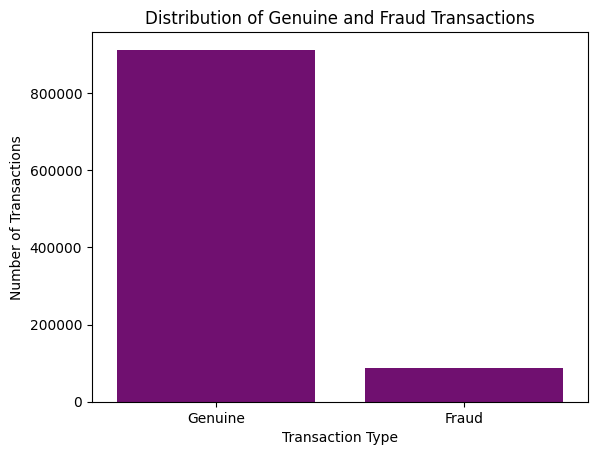

In [12]:
sns.countplot(x="fraud", data=df, color="purple")

plt.title("Distribution of Genuine and Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

# There are significantly more genuine transactions than fraudulent transactions.

## 12. Purchase Price Ratio vs Fraud

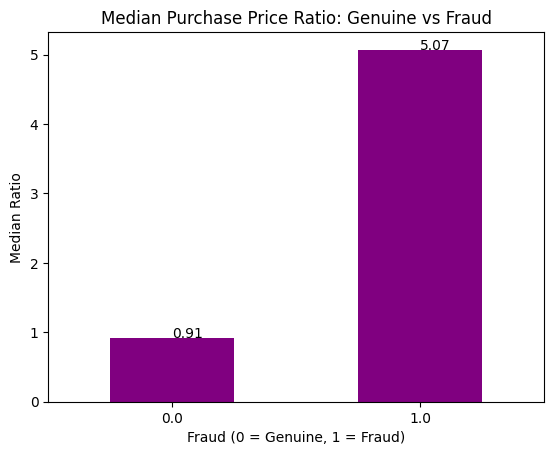

In [13]:
median_ratio = df.groupby("fraud")["ratio_to_median_purchase_price"].median()

median_ratio.plot(kind="bar", color="purple")

plt.title("Median Purchase Price Ratio: Genuine vs Fraud")
plt.xlabel("Fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Median Ratio")

plt.text(0, median_ratio.iloc[0], f"{median_ratio.iloc[0]:.2f}")
plt.text(1, median_ratio.iloc[1], f"{median_ratio.iloc[1]:.2f}")

plt.xticks(rotation=0)
plt.show()

#Fraudulent transactions have a much higher median purchase-price ratio than genuine transactions in this dataset.

## 13. Distance From Home vs Fraud

,distance_from_home
fraud,
0.0,9.673847
1.0,15.454219


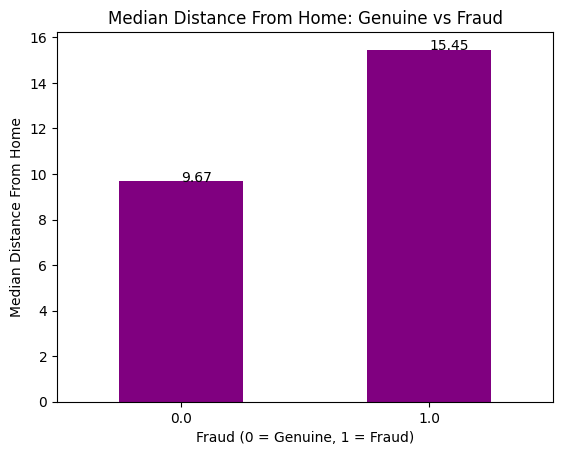

In [14]:
dist_median = df.groupby("fraud")["distance_from_home"].median()

display(dist_median)

dist_median.plot(kind="bar", color="purple")

plt.title("Median Distance From Home: Genuine vs Fraud")
plt.xlabel("Fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Median Distance From Home")

plt.text(0, dist_median.iloc[0], f"{dist_median.iloc[0]:.2f}")
plt.text(1, dist_median.iloc[1], f"{dist_median.iloc[1]:.2f}")

plt.xticks(rotation=0)
plt.show()
# Fraudulent transactions tend to occur farther from home in this dataset.

## 14. Distance From Last Transaction vs Fraud

,distance_from_last_transaction
fraud,
0.0,0.985074
1.0,1.157631


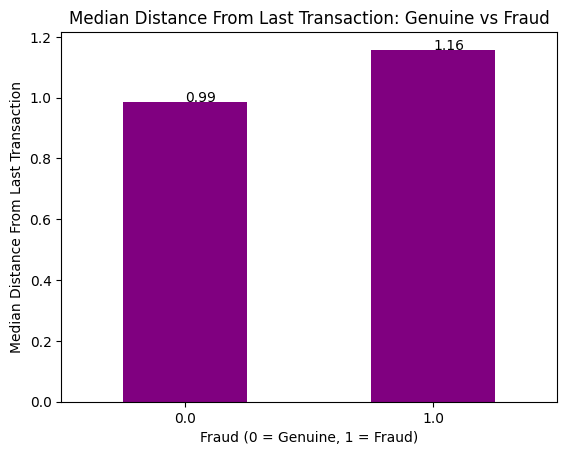

In [117]:
dist_median = df.groupby("fraud")["distance_from_last_transaction"].median()

display(dist_median)

dist_median.plot(kind="bar", color="purple")

plt.title("Median Distance From Last Transaction: Genuine vs Fraud")
plt.xlabel("Fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Median Distance From Last Transaction")

plt.text(0, dist_median.iloc[0], f"{dist_median.iloc[0]:.2f}")
plt.text(1, dist_median.iloc[1], f"{dist_median.iloc[1]:.2f}")

plt.xticks(rotation=0)
plt.show()

# Fraudulent transactions tend to have a larger distance from the previous transaction.

## 15. Online Orders vs Fraud

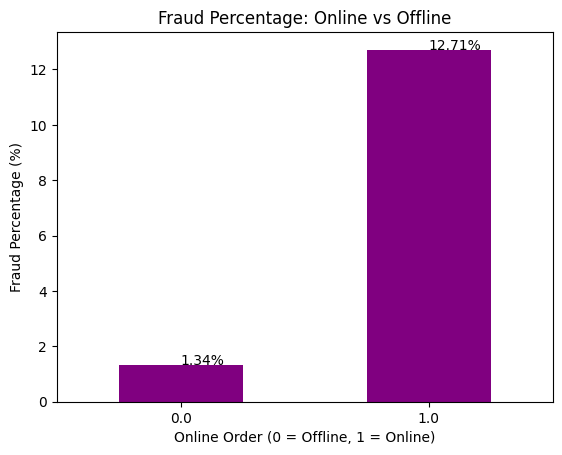

In [16]:
fraud_percent = df.groupby("online_order")["fraud"].mean() * 100

fraud_percent.plot(kind="bar", color="purple")

plt.title("Fraud Percentage: Online vs Offline")
plt.xlabel("Online Order (0 = Offline, 1 = Online)")
plt.ylabel("Fraud Percentage (%)")

plt.text(0, fraud_percent.iloc[0], f"{fraud_percent.iloc[0]:.2f}%")
plt.text(1, fraud_percent.iloc[1], f"{fraud_percent.iloc[1]:.2f}%")

plt.xticks(rotation=0)
plt.show()

# Online transactions have a higher fraud rate than offline transactions in this dataset.

## 16. Chip Usage vs Fraud

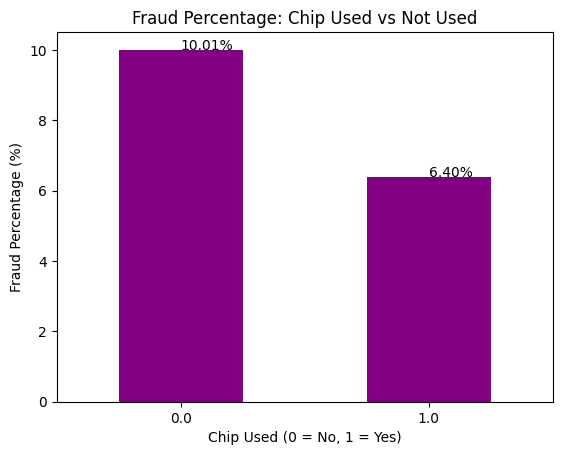

In [17]:
chip_fraud = df.groupby("used_chip")["fraud"].mean() * 100

chip_fraud.plot(kind="bar", color="purple")

plt.title("Fraud Percentage: Chip Used vs Not Used")
plt.xlabel("Chip Used (0 = No, 1 = Yes)")
plt.ylabel("Fraud Percentage (%)")

plt.text(0, chip_fraud.iloc[0], f"{chip_fraud.iloc[0]:.2f}%")
plt.text(1, chip_fraud.iloc[1], f"{chip_fraud.iloc[1]:.2f}%")

plt.xticks(rotation=0)
plt.show()

# Transactions without chip usage have a higher fraud rate in this dataset.

## 17. PIN Usage vs Fraud

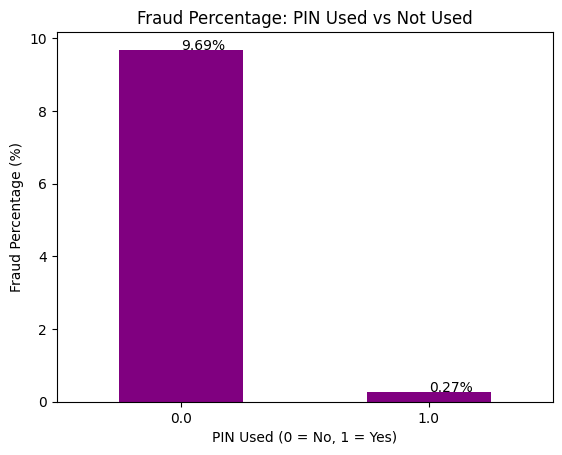

In [18]:
pin_fraud = df.groupby("used_pin_number")["fraud"].mean() * 100

pin_fraud.plot(kind="bar", color="purple")

plt.title("Fraud Percentage: PIN Used vs Not Used")
plt.xlabel("PIN Used (0 = No, 1 = Yes)")
plt.ylabel("Fraud Percentage (%)")

plt.text(0, pin_fraud.iloc[0], f"{pin_fraud.iloc[0]:.2f}%")
plt.text(1, pin_fraud.iloc[1], f"{pin_fraud.iloc[1]:.2f}%")

plt.xticks(rotation=0)
plt.show()

# Transactions without PIN usage have a higher fraud rate in this dataset.

## 18. Repeat Retailer vs Fraud

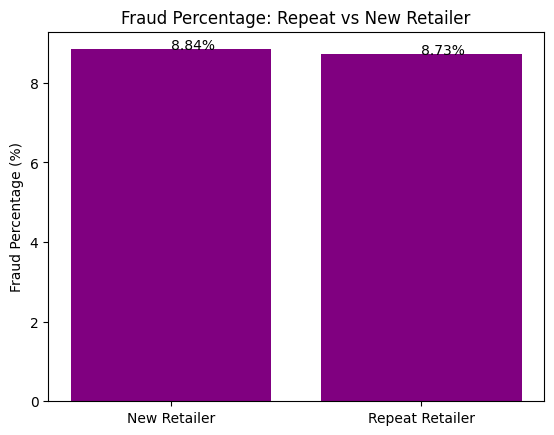

In [19]:
retailer_fraud = df.groupby("repeat_retailer")["fraud"].mean() * 100

plt.bar(["New Retailer", "Repeat Retailer"], retailer_fraud, color = 'purple')

plt.title("Fraud Percentage: Repeat vs New Retailer")
plt.ylabel("Fraud Percentage (%)")

plt.text(0, retailer_fraud.iloc[0], f"{retailer_fraud.iloc[0]:.2f}%")
plt.text(1, retailer_fraud.iloc[1], f"{retailer_fraud.iloc[1]:.2f}%")

plt.show()

## 19. Correlation Analysis

In [20]:
correlation = df.corr()
display(correlation)

# Correlation analysis shows that ratio_to_median_purchase_price has the strongest positive correlation with fraud (0.457),
# followed by online_order (0.192) and distance_from_home (0.182). However, correlation alone does not determine feature importance,
# as machine-learning models can capture nonlinear relationships and interactions

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,0.000193,-0.001374,0.143124,-0.000697,-0.001622,-0.001301,0.187571
distance_from_last_transaction,0.000193,1.000000,0.001013,-0.000928,0.002055,-0.000899,0.000141,0.091917
ratio_to_median_purchase_price,-0.001374,0.001013,1.000000,0.001374,0.000587,0.000942,-0.000330,0.462305
repeat_retailer,0.143124,-0.000928,0.001374,1.000000,-0.001345,-0.000417,-0.000532,-0.001357
used_chip,-0.000697,0.002055,0.000587,-0.001345,1.000000,-0.001393,-0.000219,-0.060975
used_pin_number,-0.001622,-0.000899,0.000942,-0.000417,-0.001393,1.000000,-0.000291,-0.100293
online_order,-0.001301,0.000141,-0.000330,-0.000532,-0.000219,-0.000291,1.000000,0.191973
fraud,0.187571,0.091917,0.462305,-0.001357,-0.060975,-0.100293,0.191973,1.000000


## 20. Data Preparation for Machine Learning

In [21]:
# Separate Features (X) and Target (y)
x = df[['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']]
y = df['fraud']

In [22]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [23]:
print("X_train: ", x_train.shape)
print("X_test: ", x_test.shape)
print("Y_train: ", y_train.shape)
print("Y_test: ", y_test.shape)

X_train:  (800000, 7)
X_test:  (200000, 7)
Y_train:  (800000,)
Y_test:  (200000,)


In [24]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [124]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Model Evaluation

## Original Logistic Regression

In [25]:
# Fitting model
model =LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [26]:
# Coeeficient
print(f"Coefficient (slope): ",model.coef_)

# Intercept
print(f"Intercept: ",model.intercept_)

Coefficient (slope):  [[ 0.99624365  0.67681699  2.41782434 -0.20061523 -0.50346164 -4.19747638
   3.14994988]]
Intercept:  [-6.2290461]


In [27]:
# Genarate prediction on test date
y_pred = model.predict(x_test)

In [28]:
# Metrics evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("recall:",recall)
print("F1_Score:",f1)
print("Confusion_matrix:\n",confusion)

Accuracy: 0.95941
Precision: 0.8964349225167245
recall: 0.605571763629083
F1_Score: 0.7228405599180607
Confusion_matrix:
 [[181296   1223]
 [  6895  10586]]


In [118]:
print("INSIGHTS")
print("Logistic Regression achieved an accuracy of 95.94%, precision of 89.64%, recall of 60.56%, and F1-score of 72.28%.")
print("The model has good precision, but its recall is relatively low, meaning it misses a considerable number of actual fraudulent transactions.")
print("Therefore, Logistic Regression provides a useful baseline model, but other algorithms should also be evaluated.")

INSIGHTS
Logistic Regression achieved an accuracy of 95.94%, precision of 89.64%, recall of 60.56%, and F1-score of 72.28%.
The model has good precision, but its recall is relatively low, meaning it misses a considerable number of actual fraudulent transactions.
Therefore, Logistic Regression provides a useful baseline model, but other algorithms should also be evaluated.


## Original Decision Tree

In [30]:
# Decision Tree Model Fitting
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [31]:
# Genarate prediction on test date
y_pred_dt = model_dt.predict(x_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.999985
Precision: 0.9999427917620137
Recall: 0.999885590069218
F1 Score: 0.9999141900975372
Confusion Matrix:
 [[182518      1]
 [     2  17479]]


In [121]:
print("INSIGHTS")
print("The Decision Tree achieved exceptionally high performance, with 99.9985% accuracy, 99.9943% precision, 99.9886% recall, and 99.9914% F1-score.")
print("It correctly detected 17,479 out of 17,481 fraudulent transactions while producing only one false positive.")
print("Additional validation checks found no identical feature rows between the training and testing sets, and the target variable was not included among the input features.")

INSIGHTS
The Decision Tree achieved exceptionally high performance, with 99.9985% accuracy, 99.9943% precision, 99.9886% recall, and 99.9914% F1-score.
It correctly detected 17,479 out of 17,481 fraudulent transactions while producing only one false positive.
Additional validation checks found no identical feature rows between the training and testing sets, and the target variable was not included among the input features.


In [42]:
# Evaluating model testing training accuracy
print("Training Accuracy:", model_dt.score(x_train, y_train))
print("Testing Accuracy:", model_dt.score(x_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.999985


In [44]:
print("INSIGHTS")
print("The Decision Tree achieved 100% training accuracy and 99.9985% testing accuracy.")
print("The very small difference indicates no obvious overfitting based on accuracy.")
print("The near-perfect performance suggests that the dataset contains strong patterns that allow the model to distinguish fraudulent and genuine transactions effectively.")

INSIGHTS
The Decision Tree achieved 100% training accuracy and 99.9985% testing accuracy.
The very small difference indicates no obvious overfitting based on accuracy.
The near-perfect performance suggests that the dataset contains strong patterns that allow the model to distinguish fraudulent and genuine transactions effectively.


## Original Random Forest

In [43]:
# Random forest model fitting
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
# Genarate prediction on test date
y_pred_rf = model_rf.predict(x_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(y_test, y_pred_rf))

print("Recall:", recall_score(y_test, y_pred_rf))

print("F1 Score:", f1_score(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.99997
Precision: 1.0
Recall: 0.999656770207654
F1 Score: 0.9998283556470993
Confusion Matrix:
 [[182519      0]
 [     6  17475]]


In [45]:
# Evaluating model testing training accuracy
print("Training Accuracy:", model_rf.score(x_train, y_train))
print("Testing Accuracy:", model_rf.score(x_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.99997


In [46]:
print("INSIGHTS")
print("The Random Forest achieved 100% training accuracy and 99.997% testing accuracy.")
print("The very small difference between training and testing accuracy indicates no obvious overfitting based on accuracy.")

INSIGHTS
The Random Forest achieved 100% training accuracy and 99.997% testing accuracy.
The very small difference between training and testing accuracy indicates no obvious overfitting based on accuracy.


## Original XGBoost

In [49]:
# XGBoost model fitting
model_xgb = XGBClassifier( random_state=42,eval_metric="logloss")
model_xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [50]:
# Genarate prediction on test date
y_pred_xgb = model_xgb.predict(x_test)

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("Precision:", precision_score(y_test, y_pred_xgb))

print("Recall:", recall_score(y_test, y_pred_xgb))

print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.998185
Precision: 0.9883601506333447
Recall: 0.9909044105028316
F1 Score: 0.9896306452995115
Confusion Matrix:
 [[182315    204]
 [   159  17322]]


In [53]:
# Evaluating model testing training accuracy
print("Training Accuracy:", model_xgb.score(x_train, y_train))
print("Testing Accuracy:", model_xgb.score(x_test, y_test))

Training Accuracy: 0.998995
Testing Accuracy: 0.998185


In [54]:
print("INSIGHTS")
print("XGBoost achieved 99.8995% training accuracy and 99.8185% testing accuracy.\nThe small difference between training and testing accuracy indicates no obvious overfitting based on accuracy.\nThe model also achieved high precision, recall, and F1-score, showing strong performance in detecting fraudulent transactions.")

INSIGHTS
XGBoost achieved 99.8995% training accuracy and 99.8185% testing accuracy.
The small difference between training and testing accuracy indicates no obvious overfitting based on accuracy.
The model also achieved high precision, recall, and F1-score, showing strong performance in detecting fraudulent transactions.


## SMOTE

In [62]:
# SMOTE Object
smote = SMOTE(random_state=42)

In [63]:
# Fit SMOTE
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [64]:
# Total Fraud vs Genuine transaction distribution
print(y_train_smote.value_counts())

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


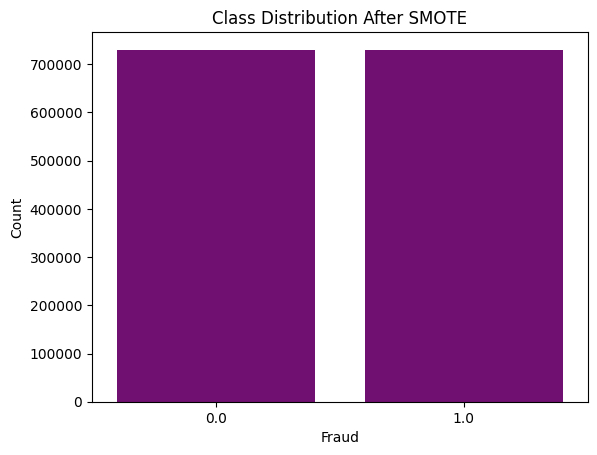

In [67]:
# Visulasing Genuine vs Fraud
sns.countplot(x=y_train_smote, color='purple')

plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()
# Dataset is balanced now

## SMOTE + Logistic Regression

In [69]:
# Logistic Regression + SMOTE model fitting
model_lr_smote = LogisticRegression()
model_lr_smote.fit(x_train_smote, y_train_smote)

LogisticRegression()

In [70]:
# Genarate prediction on test date
y_pred_lr_smote = model_lr_smote.predict(x_test)

In [71]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_smote))

print("Precision:", precision_score(y_test, y_pred_lr_smote))

print("Recall:", recall_score(y_test, y_pred_lr_smote))

print("F1 Score:", f1_score(y_test, y_pred_lr_smote))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_smote))

Accuracy: 0.9348
Precision: 0.5773504720103111
Recall: 0.9481150963903667
F1 Score: 0.7176755867324847
Confusion Matrix:
 [[170386  12133]
 [   907  16574]]


In [72]:
print("INSIGHTS")
print("After applying SMOTE, Logistic Regression achieved an accuracy of 93.48%, precision of 57.74%, recall of 94.81%, and F1-score of 71.77%.\nThe model correctly detected 16,574 fraudulent transactions, while 907 fraudulent transactions were missed. It also produced 12,133 false positives.")

INSIGHTS
After applying SMOTE, Logistic Regression achieved an accuracy of 93.48%, precision of 57.74%, recall of 94.81%, and F1-score of 71.77%.
The model correctly detected 16,574 fraudulent transactions, while 907 fraudulent transactions were missed. It also produced 12,133 false positives.


## SMOTE + Decision Tree

In [73]:
# Decision Tree + SMOTE model fitting
model_dt_smote = DecisionTreeClassifier()
model_dt_smote.fit(x_train_smote, y_train_smote)

DecisionTreeClassifier()

In [74]:
# Genarate prediction on test date
y_pred_dt_smote = model_dt_smote.predict(x_test)

In [75]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt_smote))

print("Precision:", precision_score(y_test, y_pred_dt_smote))

print("Recall:", recall_score(y_test, y_pred_dt_smote))

print("F1 Score:", f1_score(y_test, y_pred_dt_smote))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_smote))

Accuracy: 0.99995
Precision: 0.9995996568487275
Recall: 0.999828385103827
F1 Score: 0.9997140078933822
Confusion Matrix:
 [[182512      7]
 [     3  17478]]


In [76]:
print("INSIGHTS")
print("After applying SMOTE, the Decision Tree achieved 99.995% accuracy, 99.960% precision, 99.983% recall, and 99.971% F1-score.\nIt correctly detected 17,478 fraudulent transactions and missed only 3 fraudulent transactions, while producing 7 false positives.")

INSIGHTS
After applying SMOTE, the Decision Tree achieved 99.995% accuracy, 99.960% precision, 99.983% recall, and 99.971% F1-score.
It correctly detected 17,478 fraudulent transactions and missed only 3 fraudulent transactions, while producing 7 false positives.


## SMOTE + Random Forest

In [77]:
# Random Forest + SMOTE model fitting
model_rf_smote = RandomForestClassifier()
model_rf_smote.fit(x_train_smote, y_train_smote)

RandomForestClassifier()

In [78]:
# Genarate prediction on test date
y_pred_rf_smote = model_rf_smote.predict(x_test)

In [79]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))

print("Precision:", precision_score(y_test, y_pred_rf_smote))

print("Recall:", recall_score(y_test, y_pred_rf_smote))

print("F1 Score:", f1_score(y_test, y_pred_rf_smote))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_smote))

Accuracy: 0.99997
Precision: 0.999885576978088
Recall: 0.999771180138436
F1 Score: 0.9998283752860412
Confusion Matrix:
 [[182517      2]
 [     4  17477]]


In [80]:
print("INSIGTHS")
print("After applying SMOTE, the Random Forest achieved 99.997% accuracy, 99.989% precision, 99.977% recall, and 99.983% F1-score.\nIt correctly detected 17,477 fraudulent transactions and missed only 4 fraudulent transactions, while producing 2 false positives.")

INSIGTHS
After applying SMOTE, the Random Forest achieved 99.997% accuracy, 99.989% precision, 99.977% recall, and 99.983% F1-score.
It correctly detected 17,477 fraudulent transactions and missed only 4 fraudulent transactions, while producing 2 false positives.


## SMOTE + XGBoost

In [83]:
# XGBoost Forest + SMOTE model fitting
model_xgb_smote = XGBClassifier(random_state=42,eval_metric="logloss")
model_xgb_smote.fit(x_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [85]:
# Genarate prediction on test date
y_pred_xgb_smote = model_xgb_smote.predict(x_test)

In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_smote))

print("Precision:", precision_score(y_test, y_pred_xgb_smote))

print("Recall:", recall_score(y_test, y_pred_xgb_smote))

print("F1 Score:", f1_score(y_test, y_pred_xgb_smote))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_smote))

Accuracy: 0.998265
Precision: 0.9845588235294118
Recall: 0.9957668325610664
F1 Score: 0.9901311111743124
Confusion Matrix:
 [[182246    273]
 [    74  17407]]


In [87]:
print("INSIGHTS")
print("After applying SMOTE, XGBoost achieved 99.8265% accuracy, 98.456% precision, 99.577% recall, and 99.013% F1-score.\nIt correctly detected 17,407 fraudulent transactions and missed 74 fraudulent transactions, while producing 273 false positives.")

INSIGHTS
After applying SMOTE, XGBoost achieved 99.8265% accuracy, 98.456% precision, 99.577% recall, and 99.013% F1-score.
It correctly detected 17,407 fraudulent transactions and missed 74 fraudulent transactions, while producing 273 false positives.


## Comparision between Models

In [89]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy Before SMOTE": [
        0.95941,
        0.999985,
        0.99997,
        0.998185
    ],

    "Precision Before SMOTE": [
        0.8964349225,
        0.9999427918,
        1.0,
        0.9883601506
    ],

    "Recall Before SMOTE": [
        0.6055717636,
        0.9998855901,
        0.9996567702,
        0.9909044105
    ],

    "F1 Before SMOTE": [
        0.7228405599,
        0.9999141901,
        0.9998283556,
        0.9896306453
    ],

    "Accuracy After SMOTE": [
        0.9348,
        0.99995,
        0.99997,
        0.998265
    ],

    "Precision After SMOTE": [
        0.5773504720,
        0.9995996568,
        0.9998855770,
        0.9845588235
    ],

    "Recall After SMOTE": [
        0.9481150964,
        0.9998283851,
        0.9997711801,
        0.9957668326
    ],

    "F1 After SMOTE": [
        0.7176755867,
        0.9997140079,
        0.9998283753,
        0.9901311112
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:] * 100

display(comparison.round(2))

,Model,Accuracy Before SMOTE,Precision Before SMOTE,Recall Before SMOTE,F1 Before SMOTE,Accuracy After SMOTE,Precision After SMOTE,Recall After SMOTE,F1 After SMOTE
0,Logistic Regression,95.94,89.64,60.56,72.28,93.48,57.74,94.81,71.77
1,Decision Tree,100.00,99.99,99.99,99.99,100.00,99.96,99.98,99.97
2,Random Forest,100.00,100.00,99.97,99.98,100.00,99.99,99.98,99.98
3,XGBoost,99.82,98.84,99.09,98.96,99.83,98.46,99.58,99.01


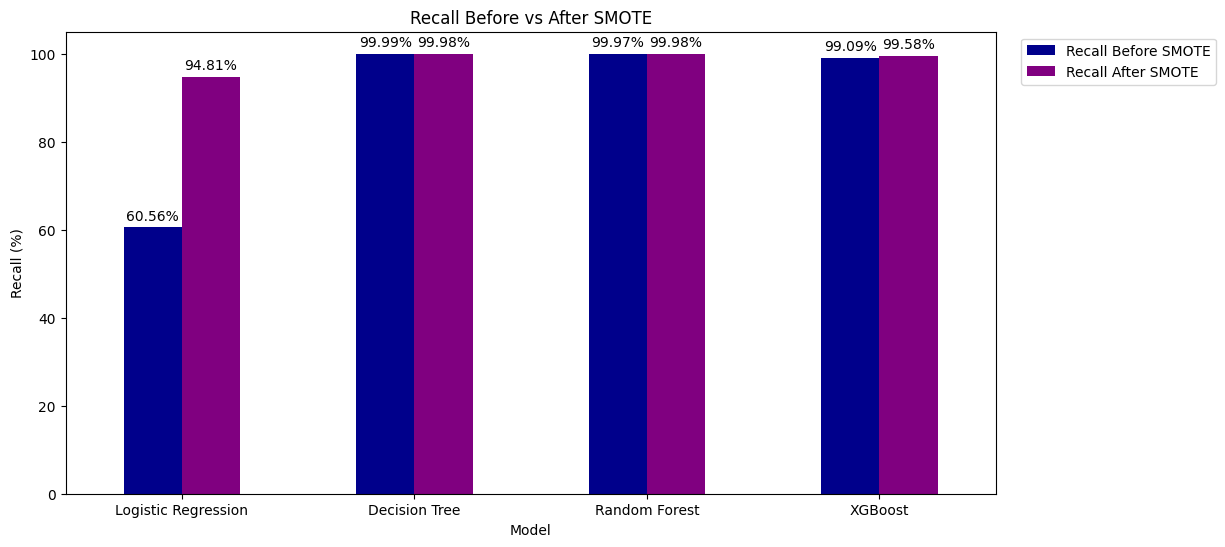

In [96]:
# Visualise Recall Comparision
ax = comparison.plot(x="Model", y=["Recall Before SMOTE", "Recall After SMOTE"], color=["darkblue", "purple"], kind="bar", figsize=(12, 6))

plt.title("Recall Before vs After SMOTE")
plt.xlabel("Model")
plt.ylabel("Recall (%)")
plt.xticks(rotation=0)


plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
plt.show()

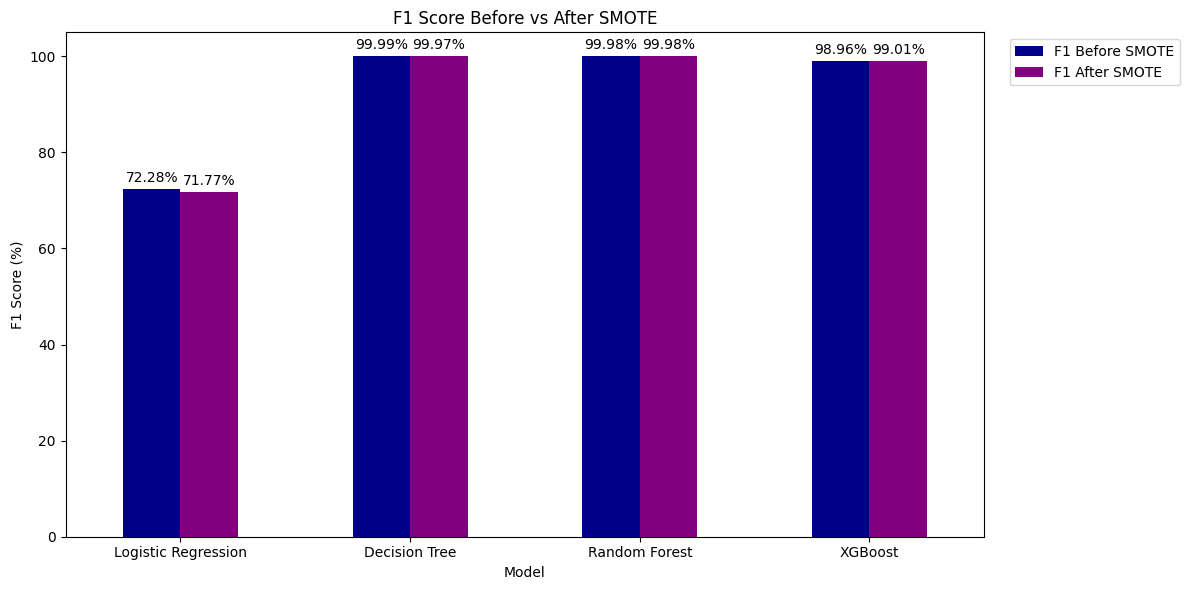

In [97]:
# Visualise F1 score Comparision
ax = comparison.plot(x="Model", y=["F1 Before SMOTE", "F1 After SMOTE"], kind="bar", figsize=(12, 6), color=["darkblue", "purple"])

plt.title("F1 Score Before vs After SMOTE")
plt.xlabel("Model")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()
plt.show()

## 22. FINAL CONCLUSION

Among the four evaluated models, the Decision Tree without SMOTE achieved the best performance based on the evaluated metrics, with 99.9985% accuracy, 99.9943% precision, 99.9886% recall, and 99.9914% F1-score. It correctly detected 17,479 fraudulent transactions and missed only 2. Although SMOTE substantially improved the recall of Logistic Regression and slightly improved XGBoost, it did not provide a meaningful improvement for the tree-based models. Therefore, the Decision Tree without SMOTE was selected as the final model for this fraud detection task.

## Train-Test Validation

In [120]:
# Model Validation Checks
# Check features
print("Features used:")
print(x.columns)

# Check train and test size
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

# Check duplicate feature rows between train and test
train_data = pd.DataFrame(x_train)
test_data = pd.DataFrame(x_test)

overlap = pd.merge(train_data, test_data, how="inner")

print("Duplicate rows in both train and test:", len(overlap))

Features used:
Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order'],
      dtype='object')
Training data: (800000, 7)
Testing data: (200000, 7)
Duplicate rows in both train and test: 0


In [111]:
# The factors which are  most useful for detecting fraud
importance = model_dt.feature_importances_ * 100

for feature, value in zip(x.columns, importance):
    print(feature, f"{value:.2f}%")

distance_from_home 10.94%
distance_from_last_transaction 3.48%
ratio_to_median_purchase_price 42.26%
repeat_retailer 0.31%
used_chip 6.78%
used_pin_number 10.48%
online_order 25.75%


In [112]:
print("Feature importance analysis showed that the ratio to median purchase price was the most influential feature (42.26%), followed by online order (25.75%).\nDistance from home (10.94%) and PIN usage (10.48%) also contributed to the model's decisions, while repeat retailer had the lowest importance (0.31%).")

Feature importance analysis showed that the ratio to median purchase price was the most influential feature (42.26%), followed by online order (25.75%).
Distance from home (10.94%) and PIN usage (10.48%) also contributed to the model's decisions, while repeat retailer had the lowest importance (0.31%).


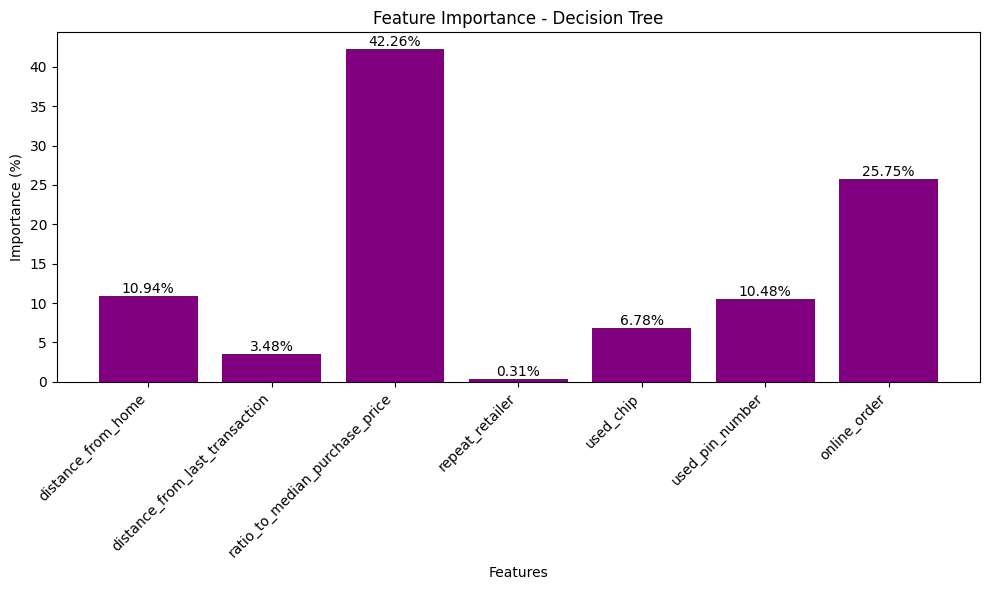

In [114]:
# Visualize Feature Importance
importance = model_dt.feature_importances_ * 100

plt.figure(figsize=(10, 6))

plt.bar(x.columns, importance, color='purple')

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance (%)")

plt.xticks(rotation=45, ha="right")

for i, value in enumerate(importance):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 23 Save Model

In [123]:
import joblib

joblib.dump(model_dt, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']